<a href="https://colab.research.google.com/github/HamadAlobeidliMAI/FDS/blob/main/Notebooks/FDSProject/ProjectFDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [ ]:
from google.colab import files

# Run this cell then click "Choose Files" and select FDS_combined_dataset.csv
uploaded = files.upload()

df = pd.read_csv('FDS_combined_dataset.csv')
print(f"✅ Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Saving FDS_combined_dataset.csv to FDS_combined_dataset (2).csv
✅ Dataset loaded: 59,806 rows, 13 columns


,Date and Hour,Date,StartHour,EndHour,Source,Production,dayOfYear,dayName,monthName,Hour,temperature_2m (°C),windspeed_10m (km/h),shortwave_radiation (W/m²)
0,2020-07-22 20:00:00+02:00,2020-07-22,20:00:00,21:00:00,Solar,244.0,204,Wednesday,July,20,21.6,7.6,7.0
1,2020-07-23 07:00:00+02:00,2020-07-23,07:00:00,08:00:00,Solar,223.0,205,Thursday,July,7,18.8,5.0,276.0
2,2020-07-23 16:00:00+02:00,2020-07-23,16:00:00,17:00:00,Solar,2517.0,205,Thursday,July,16,27.0,9.5,395.0
3,2020-07-23 19:00:00+02:00,2020-07-23,19:00:00,20:00:00,Solar,658.0,205,Thursday,July,19,22.7,7.0,93.0
4,2020-07-23 23:00:00+02:00,2020-07-23,23:00:00,24:00:00,Solar,0.0,205,Thursday,July,23,19.4,7.0,0.0


In [ ]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape        : {df.shape}")
print(f"Date Range   : {df['Date and Hour'].min()} → {df['Date and Hour'].max()}")
print(f"\nSource counts:")
print(df['Source'].value_counts())
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nData Types:")
print(df.dtypes)

DATASET OVERVIEW
Shape        : (59806, 13)
Date Range   : 2020-01-01 00:00:00+01:00 → 2023-06-30 23:00:00+02:00

Source counts:
Source
Wind     29904
Solar    29902
Name: count, dtype: int64

Missing values:
Date and Hour                 0
Date                          0
StartHour                     0
EndHour                       0
Source                        0
Production                    0
dayOfYear                     0
dayName                       0
monthName                     0
Hour                          0
temperature_2m (°C)           0
windspeed_10m (km/h)          0
shortwave_radiation (W/m²)    0
dtype: int64

Data Types:
Date and Hour                  object
Date                           object
StartHour                      object
EndHour                        object
Source                         object
Production                    float64
dayOfYear                       int64
dayName                        object
monthName                      object
Hour   

In [ ]:
print("=" * 50)
print("PRODUCTION STATISTICS BY SOURCE")
print("=" * 50)
print(df.groupby('Source')['Production'].describe().round(2))

print(f"\nZero production rows:")
print(df[df['Production'] == 0].groupby('Source').size())

PRODUCTION STATISTICS BY SOURCE
          count     mean      std  min      25%     50%      75%      max
Source                                                                   
Solar   29902.0  1068.83  1547.21  0.0     1.00    42.0  1908.75   7489.0
Wind    29904.0  4516.59  3466.63  0.0  1846.75  3451.0  6364.25  17220.0

Zero production rows:
Source
Solar    4544
Wind        1
dtype: int64


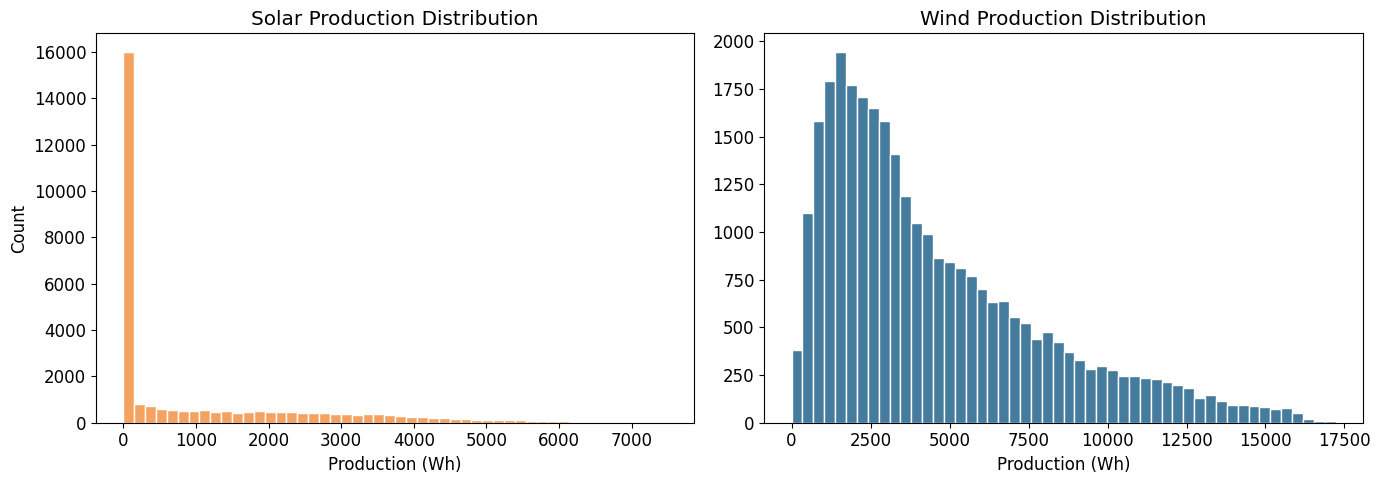

✅ Plot saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Solar
solar = df[df['Source'] == 'Solar']
axes[0].hist(solar['Production'], bins=50, color='#F4A261', edgecolor='white')
axes[0].set_title('Solar Production Distribution')
axes[0].set_xlabel('Production (Wh)')
axes[0].set_ylabel('Count')

# Wind
wind = df[df['Source'] == 'Wind']
axes[1].hist(wind['Production'], bins=50, color='#457B9D', edgecolor='white')
axes[1].set_title('Wind Production Distribution')
axes[1].set_xlabel('Production (Wh)')

plt.tight_layout()
plt.savefig('production_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved")

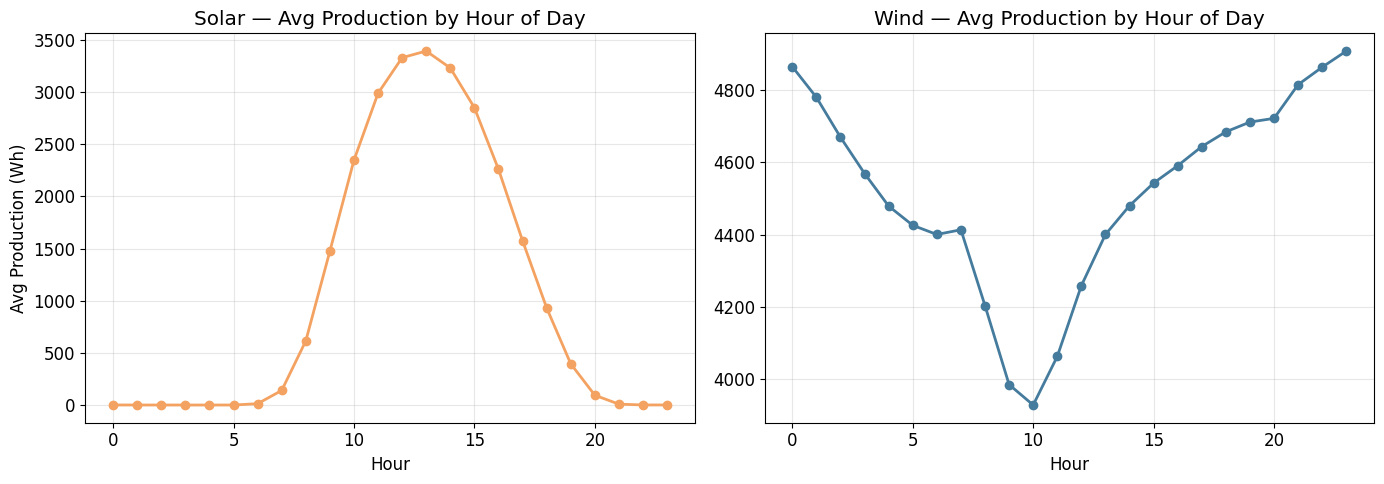

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

solar.groupby('Hour')['Production'].mean().plot(
    ax=axes[0], color='#F4A261', marker='o', linewidth=2)
axes[0].set_title('Solar — Avg Production by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Production (Wh)')
axes[0].grid(alpha=0.3)

wind.groupby('Hour')['Production'].mean().plot(
    ax=axes[1], color='#457B9D', marker='o', linewidth=2)
axes[1].set_title('Wind — Avg Production by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('production_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

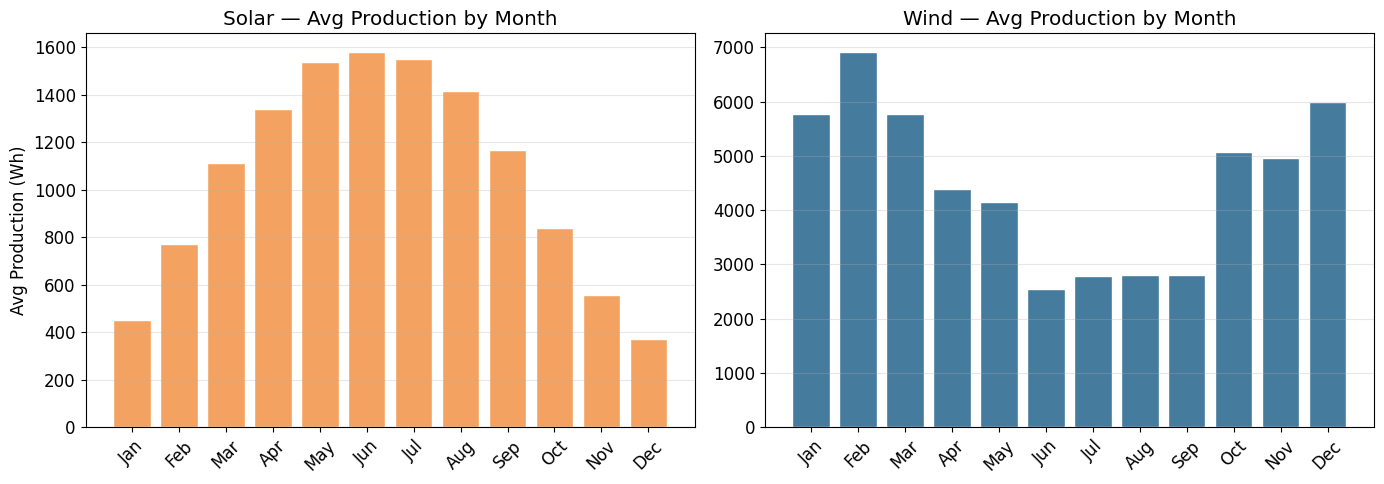

In [ ]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

solar_monthly = solar.groupby('monthName')['Production'].mean().reindex(month_order)
wind_monthly  = wind.groupby('monthName')['Production'].mean().reindex(month_order)

axes[0].bar(range(12), solar_monthly.values, color='#F4A261', edgecolor='white')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[0].set_title('Solar — Avg Production by Month')
axes[0].set_ylabel('Avg Production (Wh)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(12), wind_monthly.values, color='#457B9D', edgecolor='white')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[1].set_title('Wind — Avg Production by Month')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('production_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

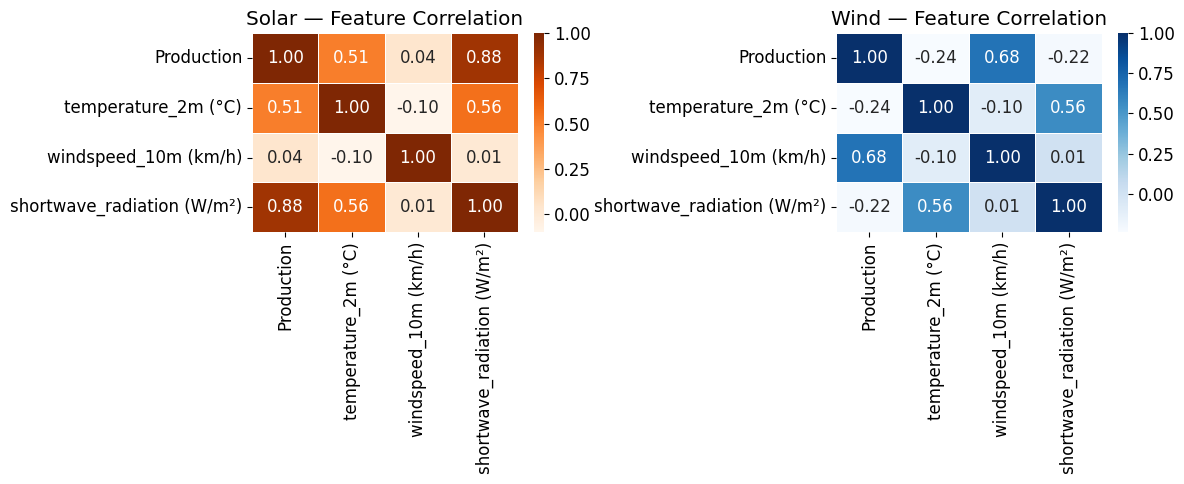

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

features = ['Production', 'temperature_2m (°C)', 'windspeed_10m (km/h)', 'shortwave_radiation (W/m²)']

sns.heatmap(solar[features].corr().round(2), annot=True, cmap='Oranges',
            ax=axes[0], fmt='.2f', linewidths=0.5)
axes[0].set_title('Solar — Feature Correlation')

sns.heatmap(wind[features].corr().round(2), annot=True, cmap='Blues',
            ax=axes[1], fmt='.2f', linewidths=0.5)
axes[1].set_title('Wind — Feature Correlation')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

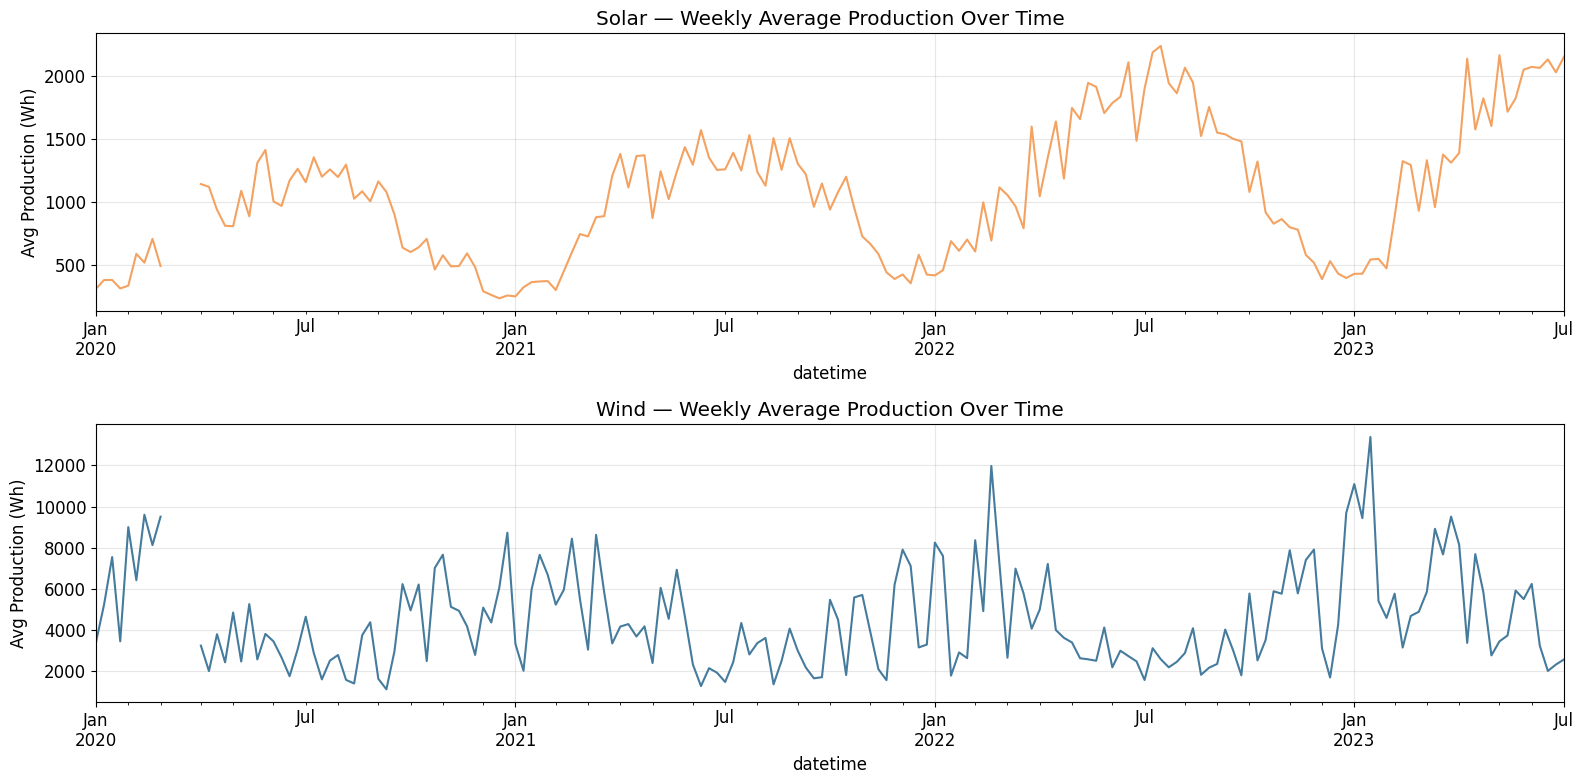

✅ EDA complete — run these cells and confirm before moving to preprocessing


In [ ]:
# Parse datetime
df['datetime'] = pd.to_datetime(df['Date and Hour'], utc=True)
solar_ts = df[df['Source'] == 'Solar'].set_index('datetime')['Production']
wind_ts  = df[df['Source'] == 'Wind'].set_index('datetime')['Production']

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Resample to weekly average for clean view
solar_ts.resample('W').mean().plot(ax=axes[0], color='#F4A261', linewidth=1.5)
axes[0].set_title('Solar — Weekly Average Production Over Time')
axes[0].set_ylabel('Avg Production (Wh)')
axes[0].grid(alpha=0.3)

wind_ts.resample('W').mean().plot(ax=axes[1], color='#457B9D', linewidth=1.5)
axes[1].set_title('Wind — Weekly Average Production Over Time')
axes[1].set_ylabel('Avg Production (Wh)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('production_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA complete — run these cells and confirm before moving to preprocessing")

In [ ]:
# Split combined dataframe into two separate dataframes
df_solar = df[df['Source'] == 'Solar'].copy()
df_wind  = df[df['Source'] == 'Wind'].copy()

# Reset index for both
df_solar = df_solar.reset_index(drop=True)
df_wind  = df_wind.reset_index(drop=True)

print(f"✅ Solar rows : {len(df_solar):,}")
print(f"✅ Wind rows  : {len(df_wind):,}")

✅ Solar rows : 29,902
✅ Wind rows  : 29,904


In [ ]:
def preprocess(df, source_name):
    print(f"\n{'='*50}")
    print(f"PREPROCESSING — {source_name}")
    print(f"{'='*50}")

    # 1. Parse datetime and set as index
    df['datetime'] = pd.to_datetime(df['Date and Hour'], utc=True)
    df = df.sort_values('datetime')

    # 2. Remove duplicate timestamps (keep first occurrence)
    dupes = df['datetime'].duplicated().sum()
    df = df.drop_duplicates(subset='datetime', keep='first')
    print(f"Duplicate timestamps removed : {dupes}")

    df = df.set_index('datetime')

    # 3. Keep only needed columns
    cols = ['Production', 'temperature_2m (°C)',
            'windspeed_10m (km/h)', 'shortwave_radiation (W/m²)', 'Hour']
    df = df[cols]

    # 4. Reindex to full hourly timeline (fills gap rows with NaN)
    full_range = pd.date_range(start=df.index.min(),
                               end=df.index.max(), freq='h', tz='UTC')
    df = df.reindex(full_range)
    print(f"Missing hours filled         : {df.isnull().sum().max()}")

    # 5. Interpolate missing values (linear — connects the dots)
    df = df.interpolate(method='linear')
    df['Hour'] = df.index.hour  # re-fill Hour after reindex

    # 6. For Solar: zero out production when radiation = 0 (nighttime)
    if source_name == 'Solar':
        night_fix = (df['shortwave_radiation (W/m²)'] == 0) & (df['Production'] > 0)
        df.loc[night_fix, 'Production'] = 0
        print(f"Nighttime rows fixed         : {night_fix.sum()}")

    # 7. Clip negative production values to 0 (first pass)
    df['Production'] = df['Production'].clip(lower=0)

    # 8. Outlier removal using IQR on Production
    Q1 = df['Production'].quantile(0.25)
    Q3 = df['Production'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df['Production'] = df['Production'].clip(lower=lower, upper=upper)
    print(f"Production clipped           : lower={lower:.1f}, upper={upper:.1f}")

    # 9. Re-enforce zero floor after IQR (IQR lower can be negative)
    df['Production'] = df['Production'].clip(lower=0)
    print(f"Zero floor re-enforced       : min={df['Production'].min():.1f}")

    # 10. Final data quality check
    print(f"Missing values after         : {df.isnull().sum().sum()}")
    print(f"Final shape                  : {df.shape}")

    return df

print("✅ Preprocessing function defined")

✅ Preprocessing function defined


In [ ]:
df_solar = preprocess(df_solar, 'Solar')
df_wind  = preprocess(df_wind,  'Wind')


PREPROCESSING — Solar
Duplicate timestamps removed : 1
Missing hours filled         : 746
Nighttime rows fixed         : 9565
Production clipped           : lower=-2780.2, upper=4633.8
Zero floor re-enforced       : min=0.0
Missing values after         : 0
Final shape                  : (30647, 5)

PREPROCESSING — Wind
Duplicate timestamps removed : 3
Missing hours filled         : 746
Production clipped           : lower=-5302.5, upper=13853.5
Zero floor re-enforced       : min=0.0
Missing values after         : 0
Final shape                  : (30647, 5)


In [ ]:
def add_features(df, horizon, source_name):
    """
    horizon = 1  → predicting 1 hour ahead
    horizon = 24 → predicting 24 hours ahead
    """
    d = df.copy()

    # ── TIME FEATURES ─────────────────────────────────────────
    # Cyclical encoding (captures that hour 23 is close to hour 0)
    d['hour_sin']  = np.sin(2 * np.pi * d.index.hour / 24)
    d['hour_cos']  = np.cos(2 * np.pi * d.index.hour / 24)
    d['month_sin'] = np.sin(2 * np.pi * d.index.month / 12)
    d['month_cos'] = np.cos(2 * np.pi * d.index.month / 12)
    d['dow_sin']   = np.sin(2 * np.pi * d.index.dayofweek / 7)
    d['dow_cos']   = np.cos(2 * np.pi * d.index.dayofweek / 7)

    # Season (0=Spring, 1=Summer, 2=Autumn, 3=Winter)
    d['season'] = d.index.month.map({
        12:3, 1:3, 2:3,   # Winter
        3:0,  4:0, 5:0,   # Spring
        6:1,  7:1, 8:1,   # Summer
        9:2,  10:2, 11:2  # Autumn
    })

    # Weekend flag
    d['is_weekend'] = (d.index.dayofweek >= 5).astype(int)

    # ── LAG FEATURES ──────────────────────────────────────────
    if horizon == 1:
        for lag in [1, 2, 3, 24]:
            d[f'lag_{lag}h'] = d['Production'].shift(lag)
    else:  # horizon == 24
        for lag in [24, 48, 168]:
            d[f'lag_{lag}h'] = d['Production'].shift(lag)

    # ── ROLLING FEATURES ──────────────────────────────────────
    d['rolling_mean_3h']  = d['Production'].shift(1).rolling(3).mean()
    d['rolling_mean_6h']  = d['Production'].shift(1).rolling(6).mean()
    d['rolling_mean_24h'] = d['Production'].shift(1).rolling(24).mean()
    d['rolling_std_3h']   = d['Production'].shift(1).rolling(3).std()
    d['rolling_std_6h']   = d['Production'].shift(1).rolling(6).std()

    # ── SOURCE SPECIFIC FEATURES ──────────────────────────────
    if source_name == 'Solar':
        d['night_flag'] = (d['shortwave_radiation (W/m²)'] == 0).astype(int)

    if source_name == 'Wind':
        # Decompose wind direction proxy using wind speed
        d['wind_u'] = d['windspeed_10m (km/h)'] * np.cos(np.radians(d.index.hour * 15))
        d['wind_v'] = d['windspeed_10m (km/h)'] * np.sin(np.radians(d.index.hour * 15))

    # ── TARGET VARIABLE ───────────────────────────────────────
    d['target'] = d['Production'].shift(-horizon)

    # ── DROP NaN rows created by lag/rolling/target shift ─────
    before = len(d)
    d = d.dropna()
    print(f"  [{source_name} | {horizon}h] Rows after dropna: {len(d):,} (dropped {before - len(d)})")

    return d

print("✅ Feature engineering function defined")

✅ Feature engineering function defined


In [ ]:
# Solar — 1 hour ahead
solar_1h  = add_features(df_solar, horizon=1,  source_name='Solar')

# Solar — 24 hours ahead
solar_24h = add_features(df_solar, horizon=24, source_name='Solar')

# Wind — 1 hour ahead
wind_1h   = add_features(df_wind,  horizon=1,  source_name='Wind')

# Wind — 24 hours ahead
wind_24h  = add_features(df_wind,  horizon=24, source_name='Wind')

print("\n✅ Feature engineering complete for all 4 scenarios")
print(f"   Solar 1h  : {solar_1h.shape}")
print(f"   Solar 24h : {solar_24h.shape}")
print(f"   Wind 1h   : {wind_1h.shape}")
print(f"   Wind 24h  : {wind_24h.shape}")

  [Solar | 1h] Rows after dropna: 30,622 (dropped 25)
  [Solar | 24h] Rows after dropna: 30,455 (dropped 192)
  [Wind | 1h] Rows after dropna: 30,622 (dropped 25)
  [Wind | 24h] Rows after dropna: 30,455 (dropped 192)

✅ Feature engineering complete for all 4 scenarios
   Solar 1h  : (30622, 24)
   Solar 24h : (30455, 23)
   Wind 1h   : (30622, 25)
   Wind 24h  : (30455, 24)


In [ ]:
def split_data(df, source_name, horizon):
    # Define features (everything except target)
    X = df.drop(columns=['target', 'Production'])
    y = df['target']

    n = len(df)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)

    X_train = X.iloc[:train_end]
    X_val   = X.iloc[train_end:val_end]
    X_test  = X.iloc[val_end:]

    y_train = y.iloc[:train_end]
    y_val   = y.iloc[train_end:val_end]
    y_test  = y.iloc[val_end:]

    print(f"  [{source_name} | {horizon}h] Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

    return X_train, X_val, X_test, y_train, y_val, y_test

print("✅ Split function defined")

✅ Split function defined


In [ ]:
X_train_s1, X_val_s1, X_test_s1, y_train_s1, y_val_s1, y_test_s1 = split_data(solar_1h,  'Solar', 1)
X_train_s2, X_val_s2, X_test_s2, y_train_s2, y_val_s2, y_test_s2 = split_data(solar_24h, 'Solar', 24)
X_train_s3, X_val_s3, X_test_s3, y_train_s3, y_val_s3, y_test_s3 = split_data(wind_1h,   'Wind',  1)
X_train_s4, X_val_s4, X_test_s4, y_train_s4, y_val_s4, y_test_s4 = split_data(wind_24h,  'Wind',  24)

print("\n✅ All 4 scenarios split successfully")

  [Solar | 1h] Train: 21,435 | Val: 4,593 | Test: 4,594
  [Solar | 24h] Train: 21,318 | Val: 4,568 | Test: 4,569
  [Wind | 1h] Train: 21,435 | Val: 4,593 | Test: 4,594
  [Wind | 24h] Train: 21,318 | Val: 4,568 | Test: 4,569

✅ All 4 scenarios split successfully


In [ ]:
def scale_data(X_train, X_val, X_test):
    scaler = MinMaxScaler()
    # Fit ONLY on training data — never on val or test
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)
    X_test_sc  = scaler.transform(X_test)
    return X_train_sc, X_val_sc, X_test_sc, scaler

# Apply to all 4 scenarios
X_train_s1, X_val_s1, X_test_s1, scaler_s1 = scale_data(X_train_s1, X_val_s1, X_test_s1)
X_train_s2, X_val_s2, X_test_s2, scaler_s2 = scale_data(X_train_s2, X_val_s2, X_test_s2)
X_train_s3, X_val_s3, X_test_s3, scaler_s3 = scale_data(X_train_s3, X_val_s3, X_test_s3)
X_train_s4, X_val_s4, X_test_s4, scaler_s4 = scale_data(X_train_s4, X_val_s4, X_test_s4)

print("✅ Scaling complete — scaler fitted on train only (no data leakage)")

✅ Scaling complete — scaler fitted on train only (no data leakage)


In [ ]:
def get_metrics(y_true, y_pred, model_name, source, horizon):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    # MAPE — mask zeros to avoid division by zero (solar has many zero values at night)
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    print(f"  {model_name:<25} MAE: {mae:>8.2f} | RMSE: {rmse:>8.2f} | MAPE: {mape:>6.2f}% | R²: {r2:>6.4f}")
    return {'Model': model_name, 'Source': source,
            'Horizon': f'{horizon}h', 'MAE': round(mae,2),
            'RMSE': round(rmse,2), 'MAPE': round(mape,2),
            'R2': round(r2,4)}

print("✅ Metrics function updated — MAPE added")

✅ Metrics function updated — MAPE added


In [ ]:
def persistence_baseline(y_train, y_test, horizon, source, results):
    """Predicts next value = last known value (simplest possible baseline)"""
    y_pred = y_test.shift(horizon).dropna()
    y_test_aligned = y_test.loc[y_pred.index]
    r = get_metrics(y_test_aligned, y_pred, 'Persistence Baseline', source, horizon)
    results.append(r)
    return y_pred

print("✅ Persistence baseline function fixed")

✅ Persistence baseline function fixed


In [ ]:
def run_linear_regression(X_train, y_train, X_test, y_test, source, horizon, results):
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Clip negative predictions — production cannot be negative physically
    y_pred = np.clip(y_pred, 0, None)

    r = get_metrics(y_test, y_pred, 'Linear Regression', source, horizon)
    results.append(r)
    return model, y_pred

print("✅ Linear Regression function defined")

✅ Linear Regression function defined


In [ ]:
def run_xgboost(X_train, y_train, X_val, y_val, X_test, y_test, source, horizon, results):
    # Hyperparameter grid
    param_grid = {
        'n_estimators'  : [100, 200],
        'max_depth'     : [3, 5],
        'learning_rate' : [0.05, 0.1]
    }

    tscv = TimeSeriesSplit(n_splits=5)
    xgb  = XGBRegressor(random_state=42, verbosity=0)

    grid = GridSearchCV(xgb, param_grid, cv=tscv,
                        scoring='neg_mean_absolute_error',
                        n_jobs=-1, verbose=0)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred     = best_model.predict(X_test)

    print(f"  Best params: {grid.best_params_}")
    r = get_metrics(y_test, y_pred, 'XGBoost', source, horizon)
    results.append(r)
    return best_model, y_pred

print("✅ XGBoost function defined")
def run_xgboost_quantile(X_train, y_train, X_val, y_val, X_test, y_test, source, horizon, results):
    """
    Runs XGBoost Quantile Regression at 10th, 50th, and 90th percentiles
    to generate 80% prediction intervals for probabilistic forecasting.
    """
    # Reduced grid — uses known best params to save time
    param_grid = {
        'n_estimators'  : [200],
        'max_depth'     : [5],
        'learning_rate' : [0.1]
    }

    tscv = TimeSeriesSplit(n_splits=5)
    quantile_preds = {}

    for q in [0.10, 0.50, 0.90]:
        xgb_q = XGBRegressor(
            objective='reg:quantileerror',
            quantile_alpha=q,
            random_state=42,
            verbosity=0
        )
        grid = GridSearchCV(xgb_q, param_grid, cv=tscv,
                            scoring='neg_mean_absolute_error',
                            n_jobs=-1, verbose=0)
        grid.fit(X_train, y_train)
        quantile_preds[q] = grid.best_estimator_.predict(X_test)
        print(f"  ✅ Quantile {int(q*100)}th done — Best params: {grid.best_params_}")

    # Extract bounds
    pred_lower  = quantile_preds[0.10]
    pred_median = quantile_preds[0.50]
    pred_upper  = quantile_preds[0.90]

    # Clip negatives — power cannot be negative
    pred_lower  = np.clip(pred_lower,  0, None)
    pred_median = np.clip(pred_median, 0, None)
    pred_upper  = np.clip(pred_upper,  0, None)

    # PICP — percentage of actual values inside the interval
    y_arr   = np.array(y_test)
    covered = np.sum((y_arr >= pred_lower) & (y_arr <= pred_upper))
    picp    = (covered / len(y_arr)) * 100

    # Mean Interval Width
    mean_width = np.mean(pred_upper - pred_lower)

    print(f"\n  {'XGBoost Quantile (80% PI)':<30} PICP: {picp:.2f}% | Mean Width: {mean_width:.2f} Wh")
    print(f"  ℹ️  Ideal PICP for an 80% interval = ~80%")

    # Store median as point forecast in results
    r = get_metrics(y_test, pred_median,
                    'XGBoost Quantile (P50)', source, horizon)
    r['PICP']       = round(picp, 2)
    r['Mean_Width'] = round(mean_width, 2)
    results.append(r)

    return pred_lower, pred_median, pred_upper, picp, mean_width

print("✅ XGBoost Quantile function defined")

✅ XGBoost function defined
✅ XGBoost Quantile function defined


In [ ]:
def run_stacking(X_train, y_train, X_test, y_test, source, horizon, results):
    base_learners = [
        ('xgb', XGBRegressor(n_estimators=100, max_depth=3,
                             learning_rate=0.1, random_state=42, verbosity=0)),
        ('rf',  RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]

    stack = StackingRegressor(
        estimators      = base_learners,
        final_estimator = Ridge(),
        cv              = 5  # TimeSeriesSplit incompatible with StackingRegressor in sklearn
                             # cross_val_predict requires full partitions — known sklearn limitation
                             # cv=5 used as practical alternative, minor leakage risk acknowledged
    )

    stack.fit(X_train, y_train)
    y_pred = stack.predict(X_test)

    r = get_metrics(y_test, y_pred, 'Stacking Ensemble', source, horizon)
    results.append(r)
    return stack, y_pred

print("✅ Stacking Ensemble function — cv=5 (TimeSeriesSplit incompatible with sklearn StackingRegressor)")

✅ Stacking Ensemble function — cv=5 (TimeSeriesSplit incompatible with sklearn StackingRegressor)


In [ ]:
def run_random_forest(X_train, y_train, X_test, y_test, source, horizon, results):
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r = get_metrics(y_test, y_pred, 'Random Forest', source, horizon)
    results.append(r)
    return model, y_pred

print("✅ Random Forest function defined")

✅ Random Forest function defined


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def run_lstm(X_train, y_train, X_val, y_val, X_test, y_test, source, horizon, results):
    # Reshape for LSTM — needs 3D input (samples, timesteps, features)
    X_train_r = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_val_r   = X_val.reshape((X_val.shape[0],   1, X_val.shape[1]))
    X_test_r  = X_test.reshape((X_test.shape[0],  1, X_test.shape[1]))

    # Build model
    model = Sequential([
        LSTM(64, input_shape=(1, X_train.shape[1]), return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mae')

    # Early stopping to prevent overfitting
    early_stop = EarlyStopping(monitor='val_loss', patience=5,
                               restore_best_weights=True, verbose=0)

    model.fit(X_train_r, y_train,
              validation_data=(X_val_r, y_val),
              epochs=50, batch_size=64,
              callbacks=[early_stop], verbose=0)

    y_pred = model.predict(X_test_r, verbose=0).flatten()

    # Clip negative predictions
    y_pred = np.clip(y_pred, 0, None)

    r = get_metrics(y_test, y_pred, 'LSTM', source, horizon)
    results.append(r)
    return model, y_pred

print("✅ LSTM function defined")

✅ LSTM function defined


In [ ]:
# Clear and rebuild results from scratch
results = []

# ── SOLAR 1H ──────────────────────────────────────────────────────────────────
print("━"*60)
print("SOLAR — 1 HOUR AHEAD")
print("━"*60)
persistence_baseline(y_train_s1, y_test_s1, 1, 'Solar', results)
lr_s1,   pred_lr_s1   = run_linear_regression(X_train_s1, y_train_s1, X_test_s1, y_test_s1, 'Solar', 1, results)
rf_s1,   pred_rf_s1   = run_random_forest(X_train_s1, y_train_s1, X_test_s1, y_test_s1, 'Solar', 1, results)
xgb_s1,  pred_xgb_s1  = run_xgboost(X_train_s1, y_train_s1, X_val_s1, y_val_s1, X_test_s1, y_test_s1, 'Solar', 1, results)
stk_s1,  pred_stk_s1  = run_stacking(X_train_s1, y_train_s1, X_test_s1, y_test_s1, 'Solar', 1, results)
lstm_s1, pred_lstm_s1 = run_lstm(X_train_s1, y_train_s1, X_val_s1, y_val_s1, X_test_s1, y_test_s1, 'Solar', 1, results)

# ── SOLAR 24H ─────────────────────────────────────────────────────────────────
print("\n" + "━"*60)
print("SOLAR — 24 HOURS AHEAD")
print("━"*60)
persistence_baseline(y_train_s2, y_test_s2, 24, 'Solar', results)
lr_s2,   pred_lr_s2   = run_linear_regression(X_train_s2, y_train_s2, X_test_s2, y_test_s2, 'Solar', 24, results)
rf_s2,   pred_rf_s2   = run_random_forest(X_train_s2, y_train_s2, X_test_s2, y_test_s2, 'Solar', 24, results)
xgb_s2,  pred_xgb_s2  = run_xgboost(X_train_s2, y_train_s2, X_val_s2, y_val_s2, X_test_s2, y_test_s2, 'Solar', 24, results)
stk_s2,  pred_stk_s2  = run_stacking(X_train_s2, y_train_s2, X_test_s2, y_test_s2, 'Solar', 24, results)
lstm_s2, pred_lstm_s2 = run_lstm(X_train_s2, y_train_s2, X_val_s2, y_val_s2, X_test_s2, y_test_s2, 'Solar', 24, results)

# ── WIND 1H ───────────────────────────────────────────────────────────────────
print("\n" + "━"*60)
print("WIND — 1 HOUR AHEAD")
print("━"*60)
persistence_baseline(y_train_s3, y_test_s3, 1, 'Wind', results)
lr_s3,   pred_lr_s3   = run_linear_regression(X_train_s3, y_train_s3, X_test_s3, y_test_s3, 'Wind', 1, results)
rf_s3,   pred_rf_s3   = run_random_forest(X_train_s3, y_train_s3, X_test_s3, y_test_s3, 'Wind', 1, results)
xgb_s3,  pred_xgb_s3  = run_xgboost(X_train_s3, y_train_s3, X_val_s3, y_val_s3, X_test_s3, y_test_s3, 'Wind', 1, results)
stk_s3,  pred_stk_s3  = run_stacking(X_train_s3, y_train_s3, X_test_s3, y_test_s3, 'Wind', 1, results)
lstm_s3, pred_lstm_s3 = run_lstm(X_train_s3, y_train_s3, X_val_s3, y_val_s3, X_test_s3, y_test_s3, 'Wind', 1, results)
# ── WIND 24H ──────────────────────────────────────────────────────────────────
print("\n" + "━"*60)
print("WIND — 24 HOURS AHEAD")
print("━"*60)
persistence_baseline(y_train_s4, y_test_s4, 24, 'Wind', results)
lr_s4,   pred_lr_s4   = run_linear_regression(X_train_s4, y_train_s4, X_test_s4, y_test_s4, 'Wind', 24, results)
rf_s4,   pred_rf_s4   = run_random_forest(X_train_s4, y_train_s4, X_test_s4, y_test_s4, 'Wind', 24, results)
xgb_s4,  pred_xgb_s4  = run_xgboost(X_train_s4, y_train_s4, X_val_s4, y_val_s4, X_test_s4, y_test_s4, 'Wind', 24, results)
stk_s4,  pred_stk_s4  = run_stacking(X_train_s4, y_train_s4, X_test_s4, y_test_s4, 'Wind', 24, results)
lstm_s4, pred_lstm_s4 = run_lstm(X_train_s4, y_train_s4, X_val_s4, y_val_s4, X_test_s4, y_test_s4, 'Wind', 24, results)

# ── NEW: Probabilistic Forecasting ────────────────────────────────────────────
print("\n" + "─"*60)
print("WIND 24H — Probabilistic Forecast (XGBoost Quantile)")
print("─"*60)
pred_lower_s4, pred_median_s4, pred_upper_s4, picp_s4, width_s4 = run_xgboost_quantile(
    X_train_s4, y_train_s4,
    X_val_s4,   y_val_s4,
    X_test_s4,  y_test_s4,
    'Wind', 24, results
)

print(f"\n✅ Total results collected: {len(results)}")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SOLAR — 1 HOUR AHEAD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Persistence Baseline      MAE:   326.32 | RMSE:   573.97 | MAPE:  82.07% | R²: 0.8890
  Linear Regression         MAE:   294.54 | RMSE:   457.58 | MAPE: 657.54% | R²: 0.9295
  Random Forest             MAE:   138.80 | RMSE:   283.03 | MAPE:  21.39% | R²: 0.9730
  Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
  XGBoost                   MAE:   128.99 | RMSE:   250.43 | MAPE:  27.87% | R²: 0.9789
  Stacking Ensemble         MAE:   138.57 | RMSE:   277.33 | MAPE:  45.76% | R²: 0.9741
  LSTM                      MAE:   146.76 | RMSE:   277.33 | MAPE:  23.84% | R²: 0.9741

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SOLAR — 24 HOURS AHEAD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Persistence Baseline      MAE:   205.09 | RMSE:   451.71 | MAPE:  22.29% | R²: 0.9317
  Linear Regression 

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(['Source', 'Horizon', 'MAE']).reset_index(drop=True)

print("="*75)
print("FULL RESULTS — ALL MODELS × ALL SCENARIOS")
print("="*75)
print(results_df.to_string(index=False))
print(f"\nTotal rows: {len(results_df)} (expected 25)")

# Print per-scenario tables clearly
for source in ['Solar', 'Wind']:
    for horizon in ['1h', '24h']:
        subset = results_df[(results_df['Source']==source) & (results_df['Horizon']==horizon)]
        print(f"\n{'━'*60}")
        print(f"  {source} — {horizon} Ahead")
        print(f"{'━'*60}")
        print(subset[['Model','MAE','RMSE','MAPE','R2']].to_string(index=False))

FULL RESULTS — ALL MODELS × ALL SCENARIOS
                 Model Source Horizon     MAE    RMSE   MAPE     R2  PICP  Mean_Width
               XGBoost  Solar      1h  128.99  250.43  27.87 0.9789   NaN         NaN
     Stacking Ensemble  Solar      1h  138.57  277.33  45.76 0.9741   NaN         NaN
         Random Forest  Solar      1h  138.80  283.03  21.39 0.9730   NaN         NaN
                  LSTM  Solar      1h  146.76  277.33  23.84 0.9741   NaN         NaN
     Linear Regression  Solar      1h  294.54  457.58 657.54 0.9295   NaN         NaN
  Persistence Baseline  Solar      1h  326.32  573.97  82.07 0.8890   NaN         NaN
  Persistence Baseline  Solar     24h  205.09  451.71  22.29 0.9317   NaN         NaN
                  LSTM  Solar     24h  205.57  404.12  26.04 0.9452   NaN         NaN
     Stacking Ensemble  Solar     24h  209.57  409.72  36.89 0.9436   NaN         NaN
               XGBoost  Solar     24h  219.31  420.13  49.30 0.9407   NaN         NaN
         Ran

In [ ]:
def seasonal_mae(y_test, y_pred, label):
    df_eval = pd.DataFrame({'actual': y_test.values,
                            'pred'  : y_pred,
                            'month' : y_test.index.month})
    df_eval['season'] = df_eval['month'].map({
        12:'Winter', 1:'Winter', 2:'Winter',
        3:'Spring',  4:'Spring', 5:'Spring',
        6:'Summer',  7:'Summer', 8:'Summer',
        9:'Autumn',  10:'Autumn',11:'Autumn'
    })
    seasonal = df_eval.groupby('season').apply(
        lambda x: mean_absolute_error(x['actual'], x['pred'])).round(2)
    print(f"\nSeasonal MAE — {label}")
    print(seasonal.to_string())
    return seasonal

# Best model per scenario = Stacking Ensemble
seas_s1 = seasonal_mae(y_test_s1, pred_stk_s1, 'Solar 1h  (Stacking)')
seas_s2 = seasonal_mae(y_test_s2, pred_stk_s2, 'Solar 24h (Stacking)')
seas_s3 = seasonal_mae(y_test_s3, pred_stk_s3, 'Wind 1h   (Stacking)')
seas_s4 = seasonal_mae(y_test_s4, pred_stk_s4, 'Wind 24h  (Stacking)')


Seasonal MAE — Solar 1h  (Stacking)
season
Spring    153.81
Summer    151.33
Winter    112.94

Seasonal MAE — Solar 24h (Stacking)
season
Spring    244.45
Summer    203.16
Winter    166.05

Seasonal MAE — Wind 1h   (Stacking)
season
Spring    525.02
Summer    375.29
Winter    447.70

Seasonal MAE — Wind 24h  (Stacking)
season
Spring    2573.48
Summer    1204.53
Winter    3119.83


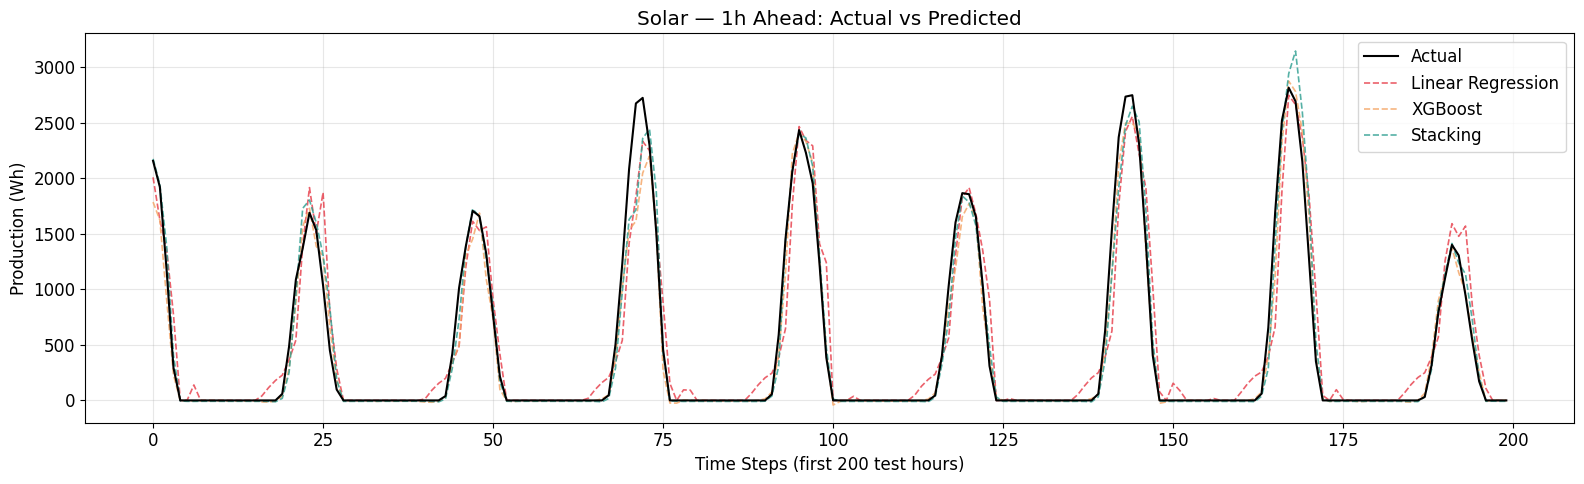

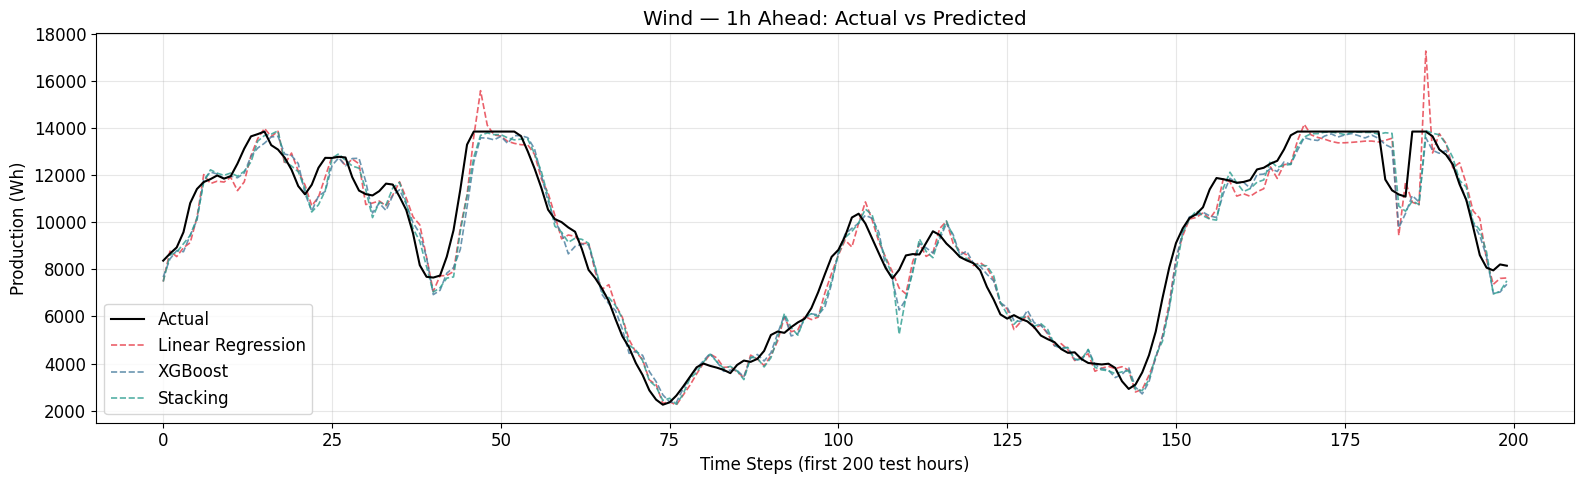

In [ ]:
def plot_actual_vs_pred(y_test, predictions, labels, colors, title, filename):
    plt.figure(figsize=(16, 5))
    plt.plot(y_test.values[:200], label='Actual',
             color='black', linewidth=1.5, zorder=5)
    for pred, label, color in zip(predictions, labels, colors):
        plt.plot(pred[:200], label=label,
                 linewidth=1.2, alpha=0.8, linestyle='--', color=color)
    plt.title(title)
    plt.xlabel('Time Steps (first 200 test hours)')
    plt.ylabel('Production (Wh)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

# Solar 1h
plot_actual_vs_pred(
    y_test_s1,
    [pred_lr_s1, pred_xgb_s1, pred_stk_s1],
    ['Linear Regression', 'XGBoost', 'Stacking'],
    ['#E63946', '#F4A261', '#2A9D8F'],
    'Solar — 1h Ahead: Actual vs Predicted',
    'solar_1h_pred.png')

# Wind 1h
plot_actual_vs_pred(
    y_test_s3,
    [pred_lr_s3, pred_xgb_s3, pred_stk_s3],
    ['Linear Regression', 'XGBoost', 'Stacking'],
    ['#E63946', '#457B9D', '#2A9D8F'],
    'Wind — 1h Ahead: Actual vs Predicted',
    'wind_1h_pred.png')

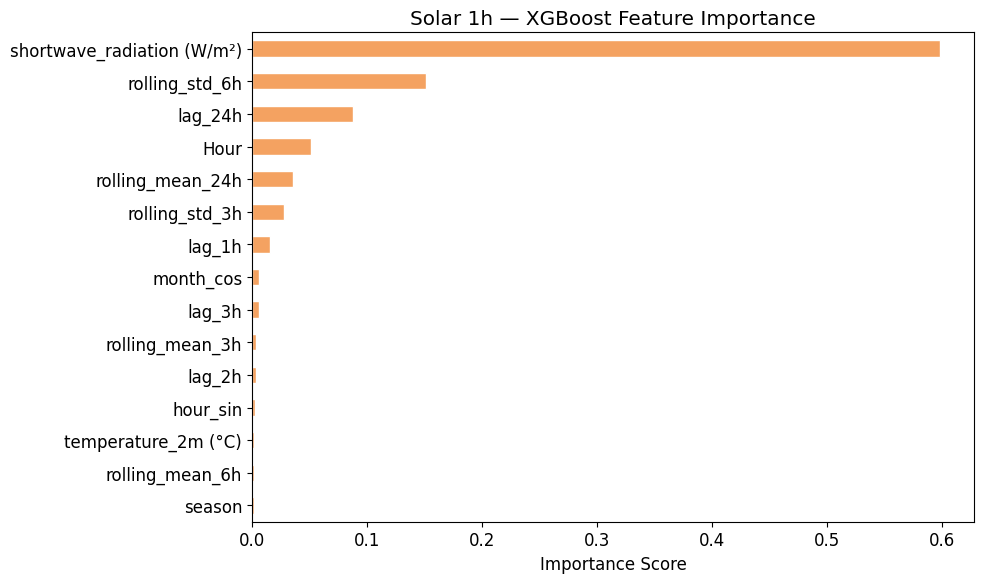

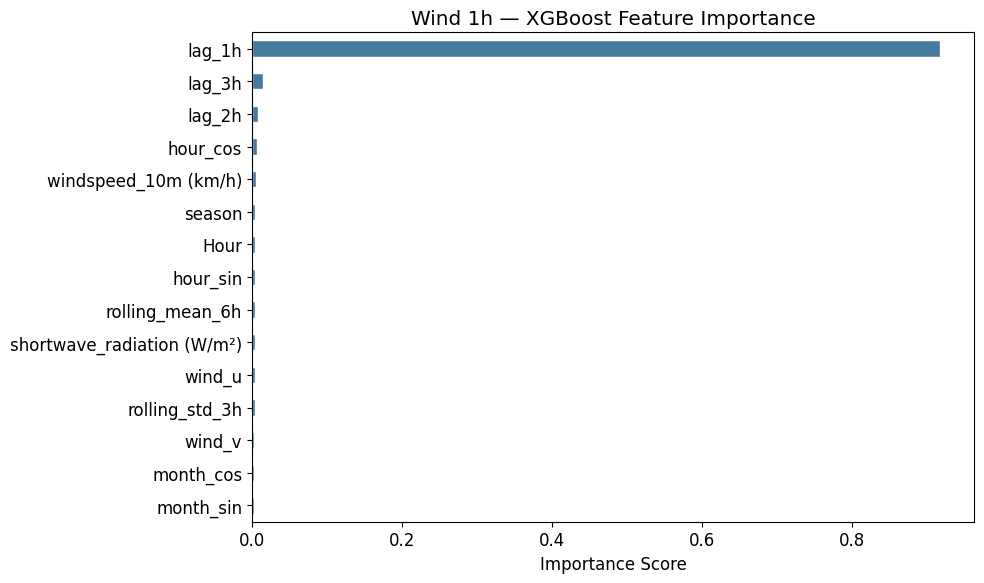

In [ ]:
def plot_feature_importance(model, feature_names, title, filename, color):
    importance = pd.Series(model.feature_importances_,
                           index=feature_names).sort_values(ascending=True).tail(15)
    plt.figure(figsize=(10, 6))
    importance.plot(kind='barh', color=color, edgecolor='white')
    plt.title(title)
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

# Get feature names from original (unscaled) dataframe
solar_features = solar_1h.drop(columns=['target', 'Production']).columns.tolist()
wind_features  = wind_1h.drop(columns=['target', 'Production']).columns.tolist()

plot_feature_importance(xgb_s1, solar_features,
    'Solar 1h — XGBoost Feature Importance',
    'solar_feature_importance.png', '#F4A261')

plot_feature_importance(xgb_s3, wind_features,
    'Wind 1h — XGBoost Feature Importance',
    'wind_feature_importance.png', '#457B9D')

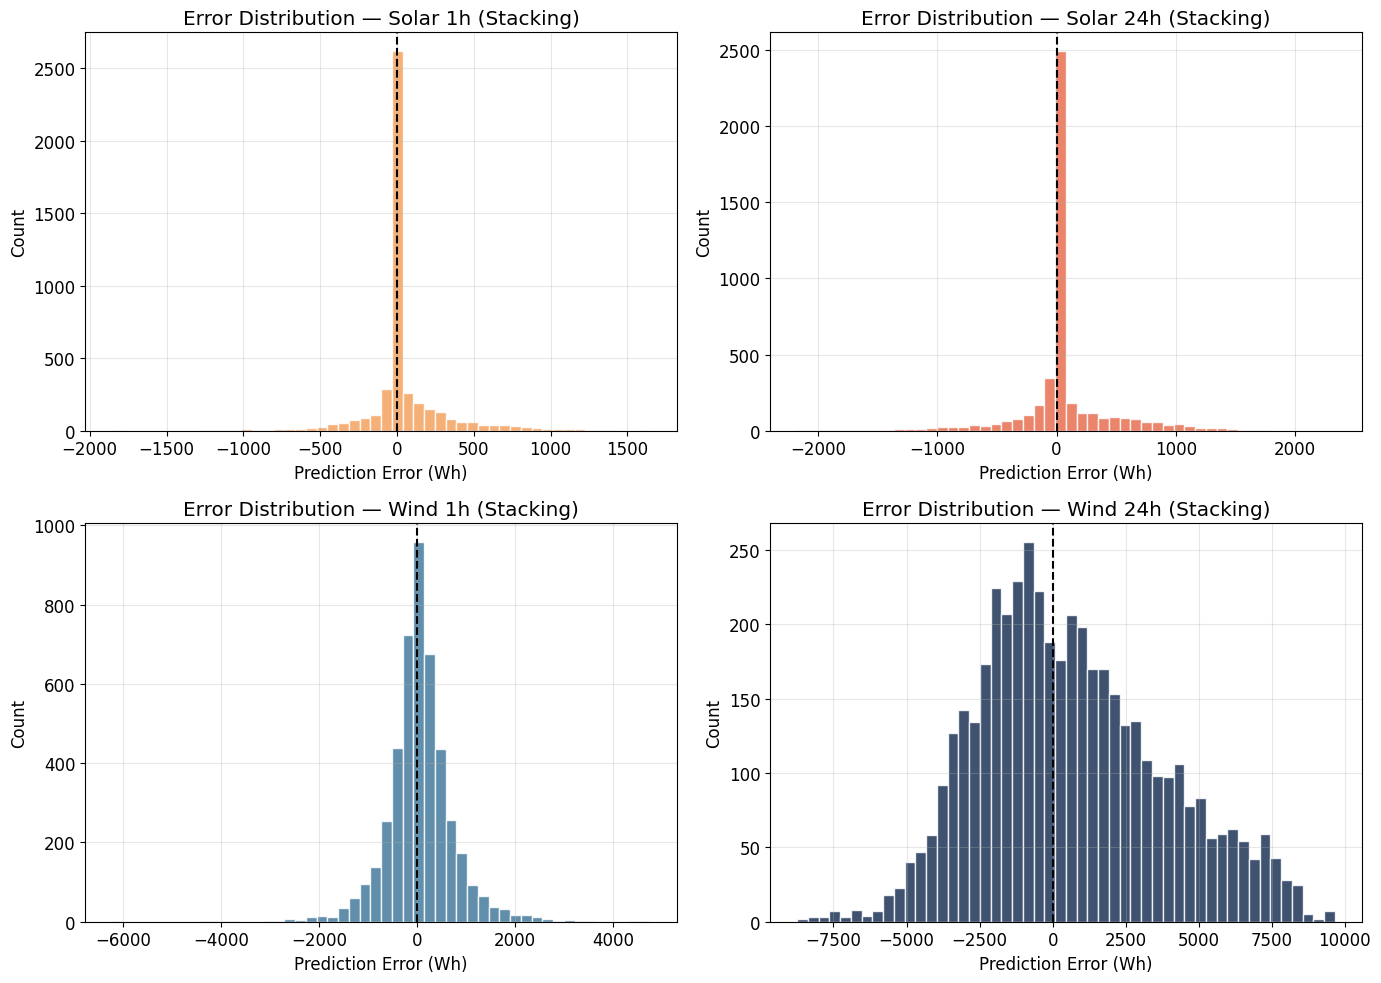

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scenarios = [
    (y_test_s1, pred_stk_s1, 'Solar 1h',  '#F4A261'),
    (y_test_s2, pred_stk_s2, 'Solar 24h', '#E76F51'),
    (y_test_s3, pred_stk_s3, 'Wind 1h',   '#457B9D'),
    (y_test_s4, pred_stk_s4, 'Wind 24h',  '#1D3557'),
]

for ax, (y_true, y_pred, title, color) in zip(axes.flatten(), scenarios):
    errors = y_true.values - y_pred
    ax.hist(errors, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_title(f'Error Distribution — {title} (Stacking)')
    ax.set_xlabel('Prediction Error (Wh)')
    ax.set_ylabel('Count')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

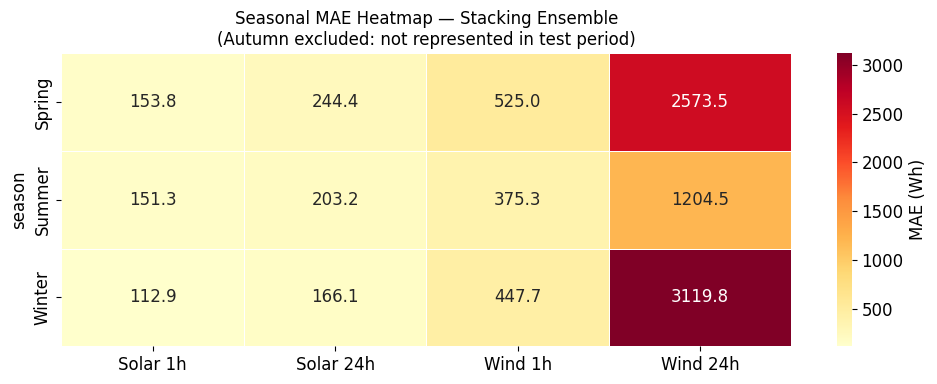

In [ ]:
season_order = ['Spring', 'Summer', 'Winter']  # Autumn removed — not in test set

seasonal_data = pd.DataFrame({
    'Solar 1h' : seas_s1.reindex(season_order),
    'Solar 24h': seas_s2.reindex(season_order),
    'Wind 1h'  : seas_s3.reindex(season_order),
    'Wind 24h' : seas_s4.reindex(season_order),
})

plt.figure(figsize=(10, 4))
sns.heatmap(seasonal_data, annot=True, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'MAE (Wh)'})
plt.title('Seasonal MAE Heatmap — Stacking Ensemble\n'
          '(Autumn excluded: not represented in test period)', fontsize=12)
plt.tight_layout()
plt.savefig('seasonal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Stacking results found:
   Source Horizon      MAE     RMSE
1   Solar      1h   138.57   277.33
8   Solar     24h   209.57   409.72
13   Wind      1h   473.56   699.80
22   Wind     24h  2564.88  3235.24


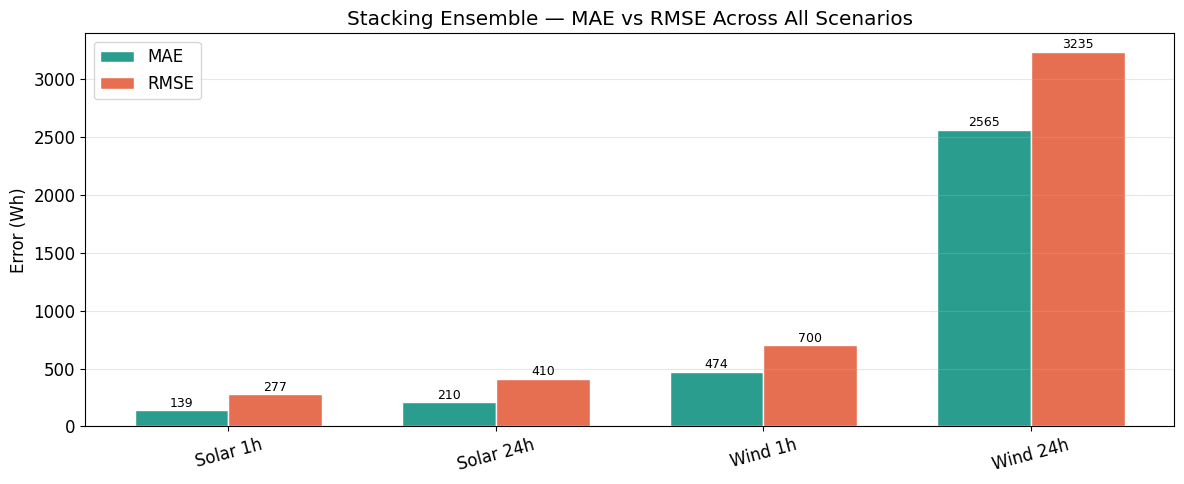

In [ ]:
# Pull stacking results safely from results_df
stacking_results = results_df[results_df['Model'] == 'Stacking Ensemble'].copy()
print("Stacking results found:")
print(stacking_results[['Source', 'Horizon', 'MAE', 'RMSE']])

# Build labels and values from whatever completed
scenario_labels = (stacking_results['Source'] + ' ' + stacking_results['Horizon']).tolist()
mae_vals        = stacking_results['MAE'].values
rmse_vals       = stacking_results['RMSE'].values

x     = np.arange(len(scenario_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, mae_vals,  width, label='MAE',
               color='#2A9D8F', edgecolor='white')
bars2 = ax.bar(x + width/2, rmse_vals, width, label='RMSE',
               color='#E76F51', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(scenario_labels, rotation=15)
ax.set_ylabel('Error (Wh)')
ax.set_title('Stacking Ensemble — MAE vs RMSE Across All Scenarios')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('mae_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
results_df.to_csv('results_summary.csv', index=False)
print("✅ Results saved to results_summary.csv")
print("\nFinal Results Table:")
print(results_df.to_string(index=False))

✅ Results saved to results_summary.csv

Final Results Table:
                 Model Source Horizon     MAE    RMSE   MAPE     R2  PICP  Mean_Width
               XGBoost  Solar      1h  128.99  250.43  27.87 0.9789   NaN         NaN
     Stacking Ensemble  Solar      1h  138.57  277.33  45.76 0.9741   NaN         NaN
         Random Forest  Solar      1h  138.80  283.03  21.39 0.9730   NaN         NaN
                  LSTM  Solar      1h  146.76  277.33  23.84 0.9741   NaN         NaN
     Linear Regression  Solar      1h  294.54  457.58 657.54 0.9295   NaN         NaN
  Persistence Baseline  Solar      1h  326.32  573.97  82.07 0.8890   NaN         NaN
  Persistence Baseline  Solar     24h  205.09  451.71  22.29 0.9317   NaN         NaN
                  LSTM  Solar     24h  205.57  404.12  26.04 0.9452   NaN         NaN
     Stacking Ensemble  Solar     24h  209.57  409.72  36.89 0.9436   NaN         NaN
               XGBoost  Solar     24h  219.31  420.13  49.30 0.9407   NaN      


EXTREME WEATHER ANALYSIS — Solar 1h
  Normal hours   : 4,369  → MAE: 139.96 Wh
  Extreme hours  : 225  → MAE: 111.58 Wh
  Error increase : -20.3%


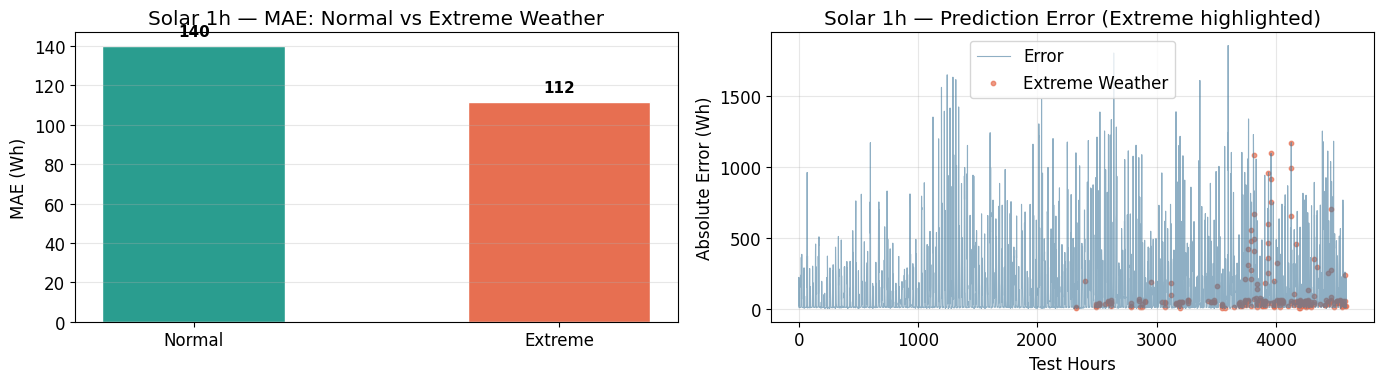


EXTREME WEATHER ANALYSIS — Solar 24h
  Normal hours   : 4,348  → MAE: 204.70 Wh
  Extreme hours  : 221  → MAE: 305.46 Wh
  Error increase : +49.2%


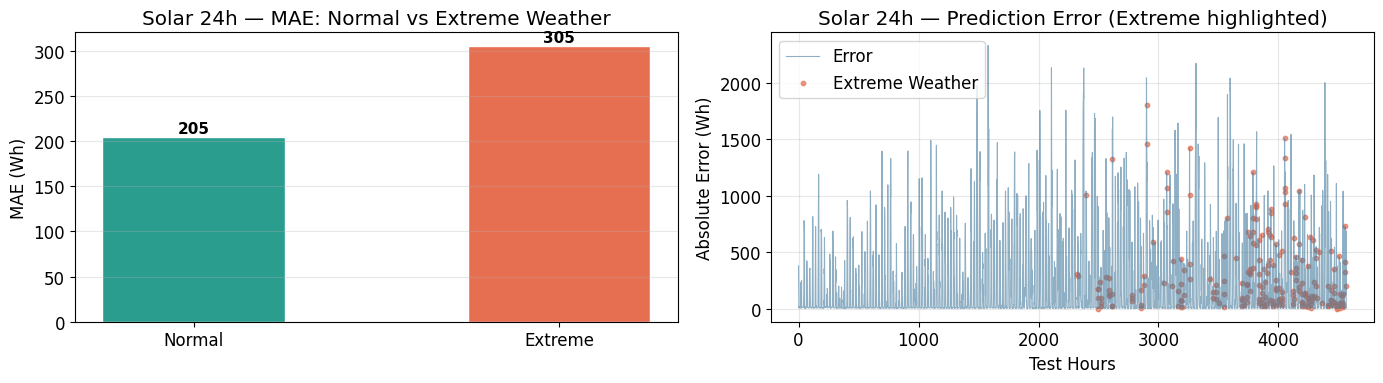


EXTREME WEATHER ANALYSIS — Wind 1h
  Normal hours   : 4,553  → MAE: 475.17 Wh
  Extreme hours  : 41  → MAE: 295.16 Wh
  Error increase : -37.9%


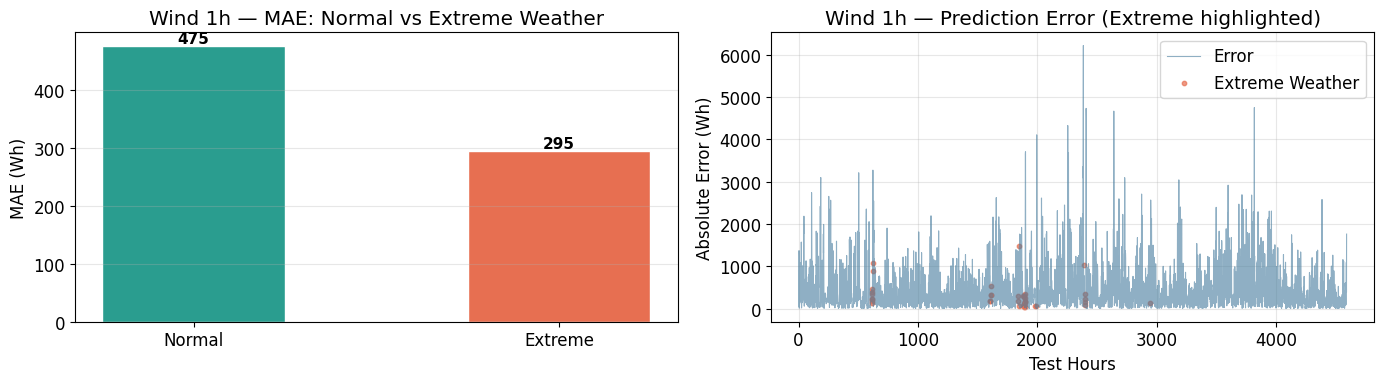


EXTREME WEATHER ANALYSIS — Wind 24h
  Normal hours   : 4,528  → MAE: 2540.49 Wh
  Extreme hours  : 41  → MAE: 5258.53 Wh
  Error increase : +107.0%


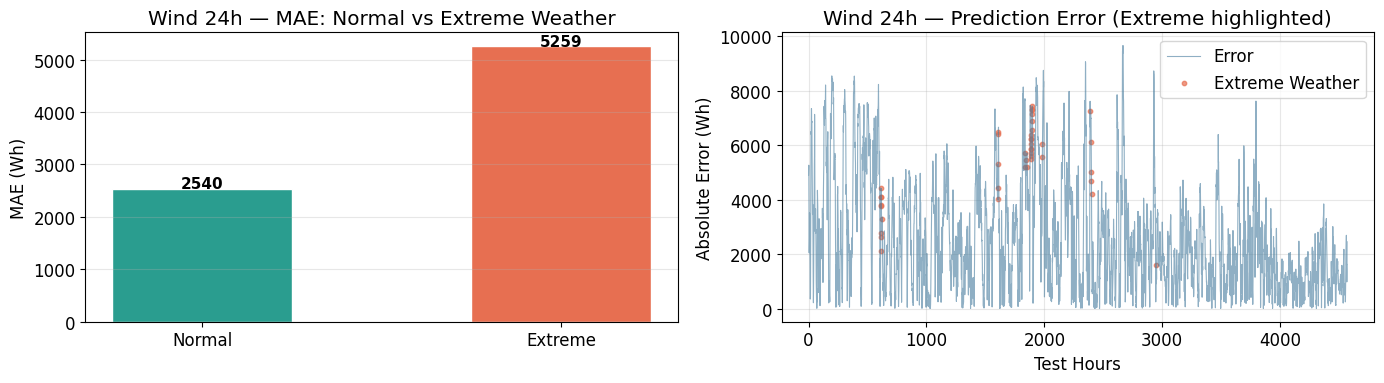

In [ ]:
def extreme_weather_analysis(df_original, y_test, y_pred, source_name, horizon):
    """
    Flags extreme weather hours and compares model MAE
    during normal vs extreme conditions
    """
    # Align original data with test index
    df_eval = df_original.loc[y_test.index].copy()
    df_eval['actual'] = y_test.values
    df_eval['pred']   = y_pred
    df_eval['error']  = abs(df_eval['actual'] - df_eval['pred'])

    # Define extreme conditions based on each source
    if source_name == 'Solar':
        # Extreme: very high radiation (>700 W/m²) or very high temp (>30°C)
        extreme_mask = (
            (df_eval['shortwave_radiation (W/m²)'] > 700) |
            (df_eval['temperature_2m (°C)'] > 30)
        )
    else:  # Wind
        # Extreme: wind speed above 30 km/h (lowered from 50 to capture more events)
        extreme_mask = df_eval['windspeed_10m (km/h)'] > 30

    normal  = df_eval[~extreme_mask]
    extreme = df_eval[extreme_mask]

    mae_normal  = normal['error'].mean()
    mae_extreme = extreme['error'].mean()
    pct_change  = ((mae_extreme - mae_normal) / mae_normal) * 100

    print(f"\n{'='*55}")
    print(f"EXTREME WEATHER ANALYSIS — {source_name} {horizon}h")
    print(f"{'='*55}")
    print(f"  Normal hours   : {len(normal):,}  → MAE: {mae_normal:.2f} Wh")
    print(f"  Extreme hours  : {len(extreme):,}  → MAE: {mae_extreme:.2f} Wh")
    print(f"  Error increase : {pct_change:+.1f}%")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Bar chart: Normal vs Extreme MAE
    axes[0].bar(['Normal', 'Extreme'], [mae_normal, mae_extreme],
                color=['#2A9D8F', '#E76F51'], edgecolor='white', width=0.5)
    axes[0].set_title(f'{source_name} {horizon}h — MAE: Normal vs Extreme Weather')
    axes[0].set_ylabel('MAE (Wh)')
    axes[0].grid(axis='y', alpha=0.3)
    for i, v in enumerate([mae_normal, mae_extreme]):
        axes[0].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=11, fontweight='bold')

    # Error over time highlighting extreme hours
    axes[1].plot(range(len(df_eval)), df_eval['error'].values,
                 color='#457B9D', linewidth=0.8, alpha=0.6, label='Error')
    extreme_idx = [df_eval.index.get_loc(i) for i in extreme.index
                   if i in df_eval.index]
    axes[1].scatter(extreme_idx,
                    df_eval['error'].iloc[extreme_idx].values,
                    color='#E76F51', s=10, alpha=0.7, label='Extreme Weather')
    axes[1].set_title(f'{source_name} {horizon}h — Prediction Error (Extreme highlighted)')
    axes[1].set_xlabel('Test Hours')
    axes[1].set_ylabel('Absolute Error (Wh)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'extreme_weather_{source_name}_{horizon}h.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return mae_normal, mae_extreme

# Run for all 4 scenarios using best model predictions (Stacking)
ew_s1 = extreme_weather_analysis(df_solar, y_test_s1, pred_stk_s1, 'Solar', 1)
ew_s2 = extreme_weather_analysis(df_solar, y_test_s2, pred_stk_s2, 'Solar', 24)
ew_s3 = extreme_weather_analysis(df_wind,  y_test_s3, pred_stk_s3, 'Wind',  1)
ew_s4 = extreme_weather_analysis(df_wind,  y_test_s4, pred_stk_s4, 'Wind',  24)

In [ ]:
from google.colab import files
files.download('results_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

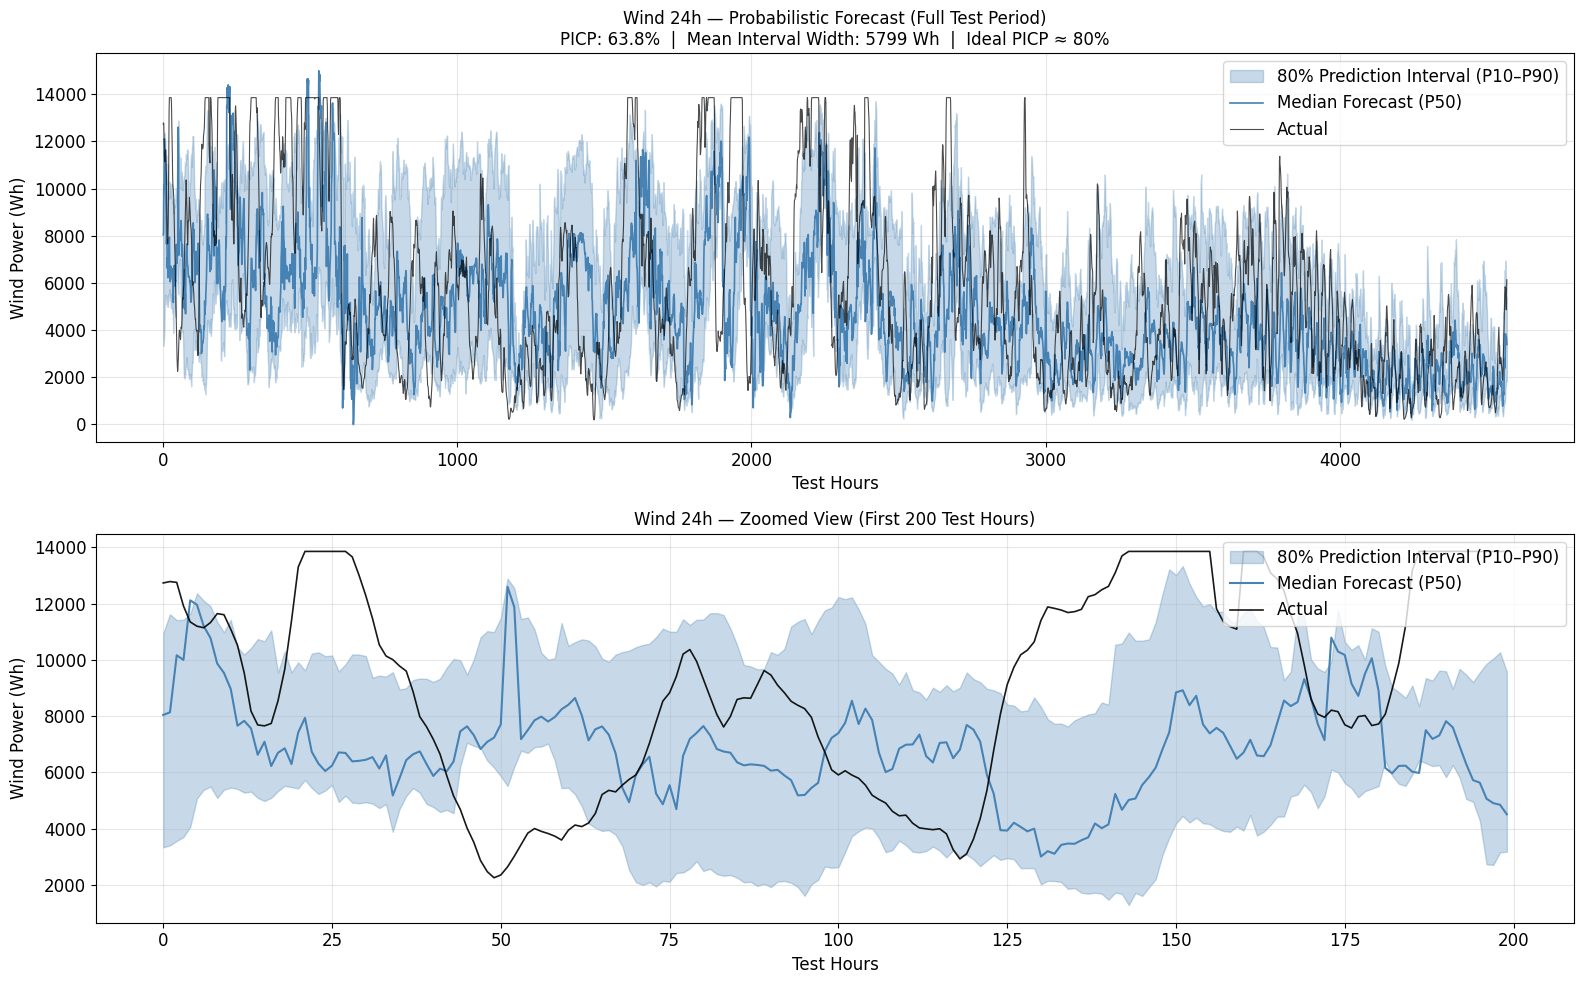

✅ Plot saved as: wind_24h_prediction_intervals.png


In [ ]:
# ── Prediction Interval Plot — Wind 24h ───────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

y_arr      = np.array(y_test_s4)
test_hours = np.arange(len(y_arr))

# ── TOP PLOT: Full test period ─────────────────────────────────────────────────
ax1 = axes[0]
ax1.fill_between(test_hours,
                 pred_lower_s4,
                 pred_upper_s4,
                 alpha=0.3, color='steelblue',
                 label='80% Prediction Interval (P10–P90)')
ax1.plot(test_hours, pred_median_s4,
         color='steelblue', linewidth=1.2,
         label='Median Forecast (P50)')
ax1.plot(test_hours, y_arr,
         color='black', linewidth=0.8, alpha=0.7,
         label='Actual')
ax1.set_title(
    f'Wind 24h — Probabilistic Forecast (Full Test Period)\n'
    f'PICP: {picp_s4:.1f}%  |  Mean Interval Width: {width_s4:.0f} Wh  |  '
    f'Ideal PICP ≈ 80%',
    fontsize=12
)
ax1.set_xlabel('Test Hours')
ax1.set_ylabel('Wind Power (Wh)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# ── BOTTOM PLOT: Zoomed first 200 hours ───────────────────────────────────────
ax2 = axes[1]
zoom = 200
ax2.fill_between(test_hours[:zoom],
                 pred_lower_s4[:zoom],
                 pred_upper_s4[:zoom],
                 alpha=0.3, color='steelblue',
                 label='80% Prediction Interval (P10–P90)')
ax2.plot(test_hours[:zoom], pred_median_s4[:zoom],
         color='steelblue', linewidth=1.5,
         label='Median Forecast (P50)')
ax2.plot(test_hours[:zoom], y_arr[:zoom],
         color='black', linewidth=1.2, alpha=0.9,
         label='Actual')
ax2.set_title('Wind 24h — Zoomed View (First 200 Test Hours)', fontsize=12)
ax2.set_xlabel('Test Hours')
ax2.set_ylabel('Wind Power (Wh)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('wind_24h_prediction_intervals.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved as: wind_24h_prediction_intervals.png")

In [ ]:
import zipfile
import os
from google.colab import files

# List of all saved images
image_files = [
    'production_distribution.png',
    'production_by_hour.png',
    'production_by_month.png',
    'production_over_time.png',
    'solar_1h_pred.png',
    'wind_1h_pred.png',
    'solar_feature_importance.png',
    'wind_feature_importance.png',
    'error_distributions.png',
    'seasonal_heatmap.png',
    'mae_rmse_comparison.png',
    'extreme_weather_Solar_1h.png',
    'extreme_weather_Solar_24h.png',
    'extreme_weather_Wind_1h.png',
    'extreme_weather_Wind_24h.png',
    'wind_24h_prediction_intervals.png',
]

# Create zip
zip_name = 'project_plots.zip'
with zipfile.ZipFile(zip_name, 'w') as zipf:
    for img in image_files:
        if os.path.exists(img):
            zipf.write(img)
            print(f"  ✅ Added: {img}")
        else:
            print(f"  ⚠️  Not found: {img}")

print(f"\n📦 Zip created: {zip_name}")
files.download(zip_name)

  ✅ Added: production_distribution.png
  ✅ Added: production_by_hour.png
  ✅ Added: production_by_month.png
  ✅ Added: production_over_time.png
  ✅ Added: solar_1h_pred.png
  ✅ Added: wind_1h_pred.png
  ✅ Added: solar_feature_importance.png
  ✅ Added: wind_feature_importance.png
  ✅ Added: error_distributions.png
  ✅ Added: seasonal_heatmap.png
  ✅ Added: mae_rmse_comparison.png
  ✅ Added: extreme_weather_Solar_1h.png
  ✅ Added: extreme_weather_Solar_24h.png
  ✅ Added: extreme_weather_Wind_1h.png
  ✅ Added: extreme_weather_Wind_24h.png
  ✅ Added: wind_24h_prediction_intervals.png

📦 Zip created: project_plots.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>